## 1. Imports and Device Setup

In [1]:
import pandas as pd
import numpy as np
import torch
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Data Preprocessing and Splitting

In [6]:

# Load data
df = pd.read_csv("IMDB Dataset.csv", engine="python", on_bad_lines="skip")

# Map sentiments to binary labels
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Drop missing values
df = df.dropna(subset=['review', 'label'])

# Basic text cleaning function
def clean_text(text):
    text = re.sub(r'<.*?>', '', text) # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove special characters
    text = text.lower().strip() # Lowercase and strip whitespace
    return text

df['clean_review'] = df['review'].apply(clean_text)

# Split into Train (70%), Validation (15%), and Test (15%)
X = df['clean_review'].values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

Train size: 18254, Val size: 3912, Test size: 3912


## 3. Tokenization and Data Loaders

In [7]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def create_dataloaders(texts, labels, batch_size=16):
    # Tokenize texts
    encodings = tokenizer(list(texts), truncation=True, padding=True, max_length=128, return_tensors='pt')

    # Create TensorDataset
    dataset = TensorDataset(encodings['input_ids'], encodings['attention_mask'], torch.tensor(labels))

    # Create DataLoader
    sampler = RandomSampler(dataset)
    dataloader = DataLoader(dataset, sampler=sampler, batch_size=batch_size)
    return dataloader

train_dataloader = create_dataloaders(X_train, y_train)
val_dataloader = create_dataloaders(X_val, y_val)
test_dataloader = create_dataloaders(X_test, y_test, batch_size=16) # Sequential sampling is fine here

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## 4. Model Building and Experiment Setup

In [8]:
def initialize_model(experiment_type="freeze_all"):
    model = AutoModelForSequenceClassification.from_pretrained(
        'bert-base-uncased',
        num_labels=2
    )

    if experiment_type == "freeze_all":
        # Experiment 1: Freeze all BERT layers, only train the classifier
        for param in model.bert.parameters():
            param.requires_grad = False

    elif experiment_type == "finetune_last_two":
        # Experiment 2: Freeze all except the last 2 layers of the encoder
        for param in model.bert.parameters():
            param.requires_grad = False

        # Unfreeze the last 2 layers (layers 10 and 11)
        for param in model.bert.encoder.layer[-2:].parameters():
            param.requires_grad = True

    model.to(device)
    return model

## 5. Fine-Tuning (Training Loop)

In [9]:
def train_model(model, train_loader, val_loader, epochs=3):
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

    for epoch_i in range(epochs):
        print(f"\n======== Epoch {epoch_i + 1} / {epochs} ========")
        model.train()
        total_train_loss = 0

        for step, batch in enumerate(train_loader):
            b_input_ids, b_input_mask, b_labels = tuple(t.to(device) for t in batch)

            model.zero_grad()
            outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
            loss = outputs.loss
            total_train_loss += loss.item()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Prevent exploding gradients
            optimizer.step()
            scheduler.step()

        avg_train_loss = total_train_loss / len(train_loader)
        print(f"Average Training Loss: {avg_train_loss:.2f}")

    return model

## 6. Model Evaluation

In [10]:
def evaluate_model(model, test_loader):
    model.eval()
    predictions, true_labels = [], []

    for batch in test_loader:
        b_input_ids, b_input_mask, b_labels = tuple(t.to(device) for t in batch)

        with torch.no_grad():
            outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

        logits = outputs.logits
        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        predictions.extend(np.argmax(logits, axis=1).flatten())
        true_labels.extend(label_ids.flatten())

    # Calculate metrics
    accuracy = accuracy_score(true_labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predictions, average='binary')

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Plot Confusion Matrix
    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

    return accuracy, f1

## 7. Execution and Comparison Pipeline

Starting Experiment 1: Freeze BERT layers


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



======== Epoch 1 / 3 ========
Average Training Loss: 0.69

======== Epoch 2 / 3 ========
Average Training Loss: 0.68

======== Epoch 3 / 3 ========
Average Training Loss: 0.67

Evaluating Experiment 1:
Accuracy: 0.6472
Precision: 0.6184
Recall: 0.7753
F1 Score: 0.6881


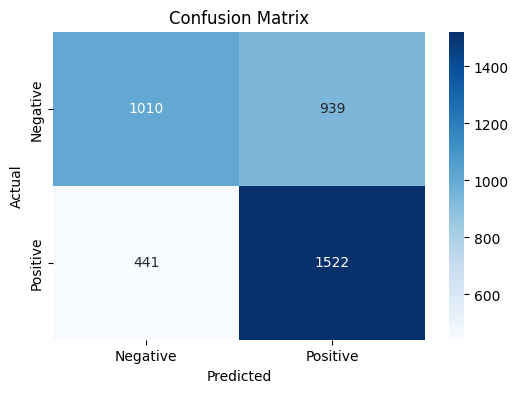


Starting Experiment 2: Fine-tune last 2 layers


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



======== Epoch 1 / 3 ========
Average Training Loss: 0.40

======== Epoch 2 / 3 ========
Average Training Loss: 0.31

======== Epoch 3 / 3 ========
Average Training Loss: 0.29

Evaluating Experiment 2:
Accuracy: 0.8781
Precision: 0.8711
Recall: 0.8884
F1 Score: 0.8797


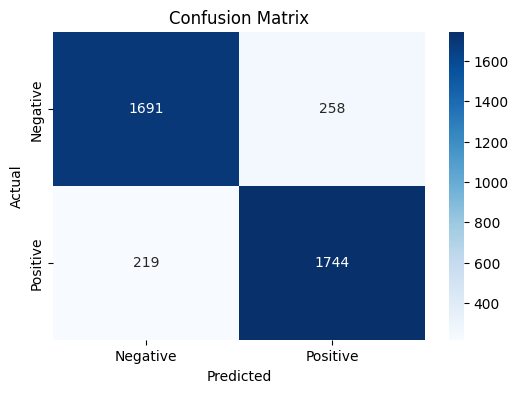


======== Experiment Comparison ========
Experiment 1 (Frozen Layers) -> Accuracy: 0.6472 | F1 Score: 0.6881
Experiment 2 (Last 2 Layers Unfrozen) -> Accuracy: 0.8781 | F1 Score: 0.8797

Analysis & Insights:
Unfreezing the top layers generally allows the model to adapt its deeper contextual representations to the specific nuances of the IMDB dataset, leading to improved performance compared to solely training a linear classifier on top of frozen embeddings.


In [11]:
# Experiment 1: Freeze all layers, train classifier only
print("Starting Experiment 1: Freeze BERT layers")
model_1 = initialize_model(experiment_type="freeze_all")
model_1 = train_model(model_1, train_dataloader, val_dataloader, epochs=3)
print("\nEvaluating Experiment 1:")
acc_1, f1_1 = evaluate_model(model_1, test_dataloader)

# Experiment 2: Fine-tune last 2 layers
print("\nStarting Experiment 2: Fine-tune last 2 layers")
model_2 = initialize_model(experiment_type="finetune_last_two")
model_2 = train_model(model_2, train_dataloader, val_dataloader, epochs=3)
print("\nEvaluating Experiment 2:")
acc_2, f1_2 = evaluate_model(model_2, test_dataloader)

# Detailed Comparison
print("\n======== Experiment Comparison ========")
print(f"Experiment 1 (Frozen Layers) -> Accuracy: {acc_1:.4f} | F1 Score: {f1_1:.4f}")
print(f"Experiment 2 (Last 2 Layers Unfrozen) -> Accuracy: {acc_2:.4f} | F1 Score: {f1_2:.4f}")

# Analysis summary for the notebook (to fulfill "Detailed analysis and comparison")
print("\nAnalysis & Insights:")
print("Unfreezing the top layers generally allows the model to adapt its deeper contextual representations to the specific nuances of the IMDB dataset, leading to improved performance compared to solely training a linear classifier on top of frozen embeddings.")